In [1]:
#useful python libraries
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from xgboost import XGBClassifier

In [2]:
#load data
df = pd.read_parquet("new_feature_space.parquet")

df.head()

,objectId,finkclass,mean,weighted_mean,standard_deviation,median,amplitude,beyond_1_std,cusum,inter_percentile_range_10,...,magnitude_percentage_ratio_20_10,maximum_slope,median_absolute_deviation,median_buffer_range_percentage_10,percent_amplitude,mean_variance,anderson_darling_normal,chi2,skew,stetson_K
0,ZTF17aaaadkj,CataclyV*,18.484376,18.013530,0.593808,18.495530,2.033953,0.149254,0.147635,0.989651,...,0.668111,778.715272,0.276399,0.368159,2.897469,0.032125,8.106756,167.142706,-2.096349,0.622763
1,ZTF17aaaakhm,CataclyV*_Candidate,19.523426,19.299517,0.428201,19.489155,1.097642,0.172414,0.155945,0.670212,...,0.733629,17.502317,0.141145,0.379310,1.275418,0.021933,1.547621,12.427528,-1.086096,0.654523
2,ZTF17aaaarmr,CataclyV*,17.558560,17.344502,0.440666,17.479678,1.323276,0.252101,0.203856,1.000527,...,0.630017,275.295240,0.220042,0.344538,1.411201,0.025097,3.421733,61.721443,0.441170,0.707557
3,ZTF17aaaazob,CataclyV*,19.060615,18.976308,0.372482,19.041963,1.092818,0.283784,0.158434,0.948873,...,0.635982,1673.060048,0.268435,0.243243,1.194768,0.019542,0.331244,7.886530,0.024982,0.788128
4,ZTF17aaaazwi,CataclyV*_Candidate,18.492340,18.099113,0.738607,18.304562,1.348280,0.363636,0.265114,1.893409,...,0.809566,40.722106,0.376825,0.121212,1.905799,0.039941,1.706506,40.696826,0.796089,0.829948


In [5]:
df.shape

(1369, 28)

In [8]:
# 1 = CataclyV (including candidates)
# 0 = everything else

y_true = df['finkclass'].apply(
    lambda x: 1 if 'Cat' in str(x) else 0
).values

print("Class distribution:")
print(pd.Series(y).value_counts())

Class distribution:
1    992
0    377
Name: count, dtype: int64


In [7]:

# Load saved model
model = joblib.load("cv_classifier_xgb_boost_biggie_set.pkl")


In [6]:
#feature space
feature_columns = df.drop(columns=['objectId', 'finkclass']).columns

X = df[feature_columns].values

In [9]:
y_pred = model.predict(X)

In [10]:
print("Unique predictions:", np.unique(y_pred))

Unique predictions: [0 1]


In [11]:
print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.6932067202337473


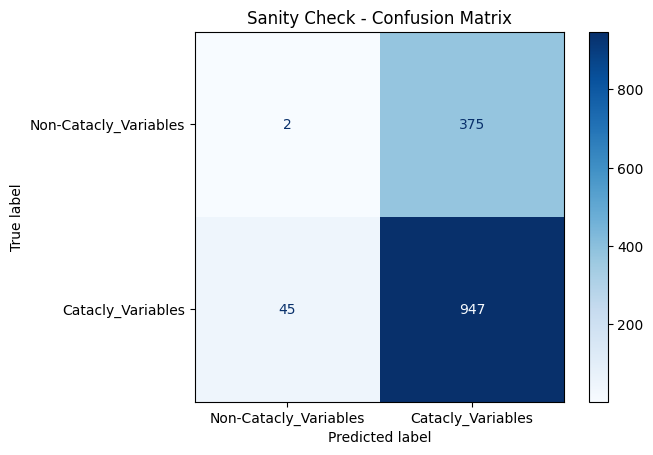

In [15]:
cm = confusion_matrix(y_true, y_pred, labels=[0,1])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Catacly_Variables", "Catacly_Variables"]
)

disp.plot(cmap=plt.cm.Blues)
plt.title("Sanity Check - Confusion Matrix")
plt.show()

In [18]:
#
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8184961106309421
